# Stage 1 — Optuna Hyperparameter Search
Cross-dataset: CATSA (train/val) → EmpaticaE4 (test)  
Signal: HRV derived from HR @ 1 Hz, window=240, stride=40  
Objective: maximise val-F1 (MedianPruner, 15 trials / model)  
Storage: SQLite (resumable)

In [9]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# RTX 4080 optimisations
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_BF16 = torch.cuda.is_available()
print(f'Device: {DEVICE}  |  BF16: {USE_BF16}')

Device: cuda  |  BF16: True


In [10]:
# ── Configuration ────────────────────────────────────────────────────────────
MODELS = [
       'TimeMixerPP', 'Medformer', 'TSLANet', 'ModernTCN',
       'CrossGNN', 'TimesNet', 'Mamba2', 'iTransformer', 'PatchTST', 'Chronos2', 'TransformerCNN',
   ]


## Signal
SIGNAL     = 'HRV'       # Derived signal name for results

# Source signal / HRV config
FS         = 1          # HR sampling rate
HRV_WINDOW = 30         # smoothing window used to derive HRV from HR
WIN_SEC    = 60
STRIDE_SEC = 10
W          = FS * WIN_SEC      # 60
STRIDE     = FS * STRIDE_SEC   # 10
N_CHANNELS = 1
TASKS        = ['Baseline', 'Logic', 'Nback', 'Stroop', 'Sudoku']
STRESS_TASKS = {'Logic', 'Nback', 'Stroop', 'Sudoku'}

# Training config
VAL_RATIO  = 0.10
EPOCHS     = 30
PATIENCE   = 7

N_TRIALS   = 15      # Optuna trials per model

# Paths
HR_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')
SAVE_DIR   = Path('Save_model_HRV_OptunaStage1')
SAVE_DIR.mkdir(exist_ok=True)
DB_PATH    = SAVE_DIR / 'optuna_studies.db'
STORAGE    = f'sqlite:///{DB_PATH}'

print(f'W={W}, stride={STRIDE}, save → {SAVE_DIR}')


W=60, stride=10, save → Save_model_HRV_OptunaStage1


In [11]:
print(MODELS)

['TimeMixerPP', 'Medformer', 'TSLANet', 'ModernTCN', 'CrossGNN', 'TimesNet', 'Mamba2', 'iTransformer', 'PatchTST', 'Chronos2', 'TransformerCNN']


In [12]:
# ── Data utilities ───────────────────────────────────────────────────────────
import re

def discover_subjects(root: Path) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.is_dir() and re.match(r'Sub\d+', p.name)])

def read_hr(path: Path) -> np.ndarray:
    df = pd.read_csv(path)
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        values = df[numeric_cols[0]].to_numpy(np.float32)
    else:
        values = pd.to_numeric(df.iloc[:, 0], errors='coerce').to_numpy(np.float32)
    return values[~np.isnan(values)]

def detect_hrv_from_hr(hr: np.ndarray, hrv_window: int = HRV_WINDOW) -> np.ndarray:
    hr = np.asarray(hr, dtype=np.float32)
    rr_ms = 60000.0 / np.clip(hr, 30.0, 220.0)
    drr = np.diff(rr_ms, prepend=rr_ms[0])

    w = max(3, int(hrv_window))
    kernel = np.ones(w, dtype=np.float32) / float(w)

    rmssd = np.sqrt(np.convolve(drr * drr, kernel, mode='same') + 1e-8)
    rr_mean = np.convolve(rr_ms, kernel, mode='same')
    rr_sq_mean = np.convolve(rr_ms * rr_ms, kernel, mode='same')
    sdnn = np.sqrt(np.maximum(rr_sq_mean - rr_mean * rr_mean, 0.0) + 1e-8)

    hrv = 0.5 * rmssd + 0.5 * sdnn
    return hrv.astype(np.float32)

def make_windows(sig: np.ndarray, lbl: np.ndarray,
                 w: int, stride: int) -> tuple[np.ndarray, np.ndarray]:
    xs, ys = [], []
    for start in range(0, len(sig) - w + 1, stride):
        xs.append(sig[start:start + w])
        ys.append(int(lbl[start:start + w].mean() >= 0.5))
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int64)

def make_windows_1d(sig: np.ndarray, w: int, stride: int) -> np.ndarray:
    if len(sig) < w:
        return np.empty((0, 1, w), np.float32)
    return np.asarray([sig[i:i + w] for i in range(0, len(sig) - w + 1, stride)], np.float32)[:, None, :]

def build_hr_arrays(root: Path, w: int, stride: int,
                       val_ratio: float = 0.10):
    xs, ys = [], []
    skipped = []
    for sub in discover_subjects(root):
        try:
            path = sub
            all_hrv = np.concatenate([detect_hrv_from_hr(read_hr(path / task / 'HR.csv')) for task in TASKS])
            mu = float(np.mean(all_hrv))
            sigma = float(np.std(all_hrv)) + 1e-8
            for task in TASKS:
                hr = read_hr(path / task / 'HR.csv')
                hrv = detect_hrv_from_hr(hr)
                norm = (hrv - mu) / sigma
                x = make_windows_1d(norm, w, stride)
                if len(x):
                    xs.append(x)
                    ys.append(np.full(len(x), int(task in STRESS_TASKS), np.int64))
        except Exception as e:
            skipped.append(f'{sub.name}: {e}')
    if skipped:
        print('Skipped subjects:')
        for item in skipped[:10]:
            print(f'  {item}')
        if len(skipped) > 10:
            print(f'  ... and {len(skipped) - 10} more')
    if not xs:
        raise RuntimeError(f'No CATSA HR data could be loaded from {root}')
    X = np.concatenate(xs)
    Y = np.concatenate(ys)
    split = max(1, int(len(X) * (1 - val_ratio)))
    return X[:split], Y[:split], X[split:], Y[split:]

print('Data utilities defined.')

Data utilities defined.


In [13]:
# ── E4 data loading (test only - never used for train/val) ───────────────────
SIGNAL = 'HRV'
E4_ROOT = Path('/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects')
SUBJECTS_E4 = [f'subject_{i:02d}' for i in range(1, 7)]


def read_hr(path: Path) -> np.ndarray:
    df = pd.read_csv(path)
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        values = df[numeric_cols[0]].to_numpy(np.float32)
    else:  values = pd.to_numeric(df.iloc[:, 0], errors='coerce').to_numpy(np.float32)
    return values[~np.isnan(values)]


In [14]:
       


def build_e4_labels(n: int, fs: int = FS):
    fixed_s = {
        'rest0': 180,
        'task1': 600,
        'rest1': 120,
        'task2': 300,
        'rest2': 120,
        'task3': 180,
        'rest3': 120,
        'rest4': 120,
        'task5': 60,
        'rest5': 120,
    }
    total_fixed_s = sum(fixed_s.values())
    task4_s = max(0, n // fs - total_fixed_s)
    segs = [
        ('rest0', 180, 0),
        ('task1', 600, 1),
        ('rest1', 120, -1),
        ('task2', 300, 1),
        ('rest2', 120, -1),
        ('task3', 180, 1),
        ('rest3', 120, -1),
        ('task4', task4_s, 1),
        ('rest4', 120, -1),
        ('task5', 60, 1),
        ('rest5', 120, -1),
    ]

    labels = np.full(n, -1, dtype=np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        if dur_s <= 0:
            continue
        end = min(cur + dur_s * fs, n)
        if end > cur:
            labels[cur:end] = lab
        cur = end
        if cur >= n:
            break
    return labels, int(task4_s)


def e4_windows(hr: np.ndarray, labels: np.ndarray, W: int, S: int):
    hrv = detect_hrv_from_hr(hr, hrv_window=HRV_WINDOW)
    mask = labels >= 0
    mu = float(np.mean(hrv[mask])) if mask.any() else float(np.mean(hrv))
    sigma = float(np.std(hrv[mask])) + 1e-8 if mask.any() else float(np.std(hrv)) + 1e-8
    norm = ((hrv - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, len(norm) - W + 1, S):
        u = np.unique(labels[i:i + W])
        if len(u) == 1 and u[0] in (0, 1):
            xs.append(norm[i:i + W])
            ys.append(int(u[0]))
    if not xs:
        return np.empty((0, 1, W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32)[:, None, :], np.asarray(ys, np.int64)


e4_data_per_subject = {}
for sub in SUBJECTS_E4:
    hr = read_hr(E4_ROOT / sub / 'HR.csv')
    labels, _ = build_e4_labels(len(hr), fs=FS)
    x, y = e4_windows(hr, labels, W, STRIDE)
    e4_data_per_subject[sub] = (x, y)
    print(f'{sub}: {len(x)} windows')

subject_01: 158 windows
subject_02: 143 windows
subject_03: 115 windows
subject_04: 118 windows
subject_05: 116 windows
subject_06: 124 windows


In [15]:
# ── Load HR data (once, shared across all models) ─────────────────────────
print('Loading HR data...', end=' ')
x_train, y_train, x_val, y_val = build_hr_arrays(HR_ROOT, W, STRIDE, VAL_RATIO)
print(f'done.  train={x_train.shape}  val={x_val.shape}')

# Class imbalance alpha for FocalLoss: fraction that is non-stress
n_stress     = (y_train == 1).sum()
n_nonstress  = (y_train == 0).sum()
FOCAL_ALPHA  = float(n_nonstress / len(y_train))
print(f'Stress={n_stress}, Non-stress={n_nonstress}, focal_alpha={FOCAL_ALPHA:.3f}')

Loading HR data... done.  train=(2919, 1, 60)  val=(325, 1, 60)
Stress=2334, Non-stress=585, focal_alpha=0.200


In [16]:
# ── Chronos-2 pipeline (optional) ────────────────────────────────────────────
chronos_pipeline = None
try:
    from chronos import ChronosPipeline
    chronos_pipeline = ChronosPipeline.from_pretrained(
        'amazon/chronos-t5-small',
        device_map=str(DEVICE),
        torch_dtype=torch.float32,
    )
    print('Chronos-2 pipeline loaded.')
except Exception as e:
    print(f'Chronos-2 unavailable: {e}')
    MODELS = [m for m in MODELS if m != 'Chronos2']
    print(f'Running without Chronos2. Models: {MODELS}')

Chronos-2 unavailable: cannot import name 'PreTrainedModel' from 'transformers' (/home/binghin2/miniconda3/envs/myenv/lib/python3.10/site-packages/transformers/__init__.py)
Running without Chronos2. Models: ['TimeMixerPP', 'Medformer', 'TSLANet', 'ModernTCN', 'CrossGNN', 'TimesNet', 'Mamba2', 'iTransformer', 'PatchTST', 'TransformerCNN']


In [17]:
# ── Import models and optuna utils ───────────────────────────────────────────
sys.path.insert(0, str(Path('.').resolve()))

from HRV_optuna_utils import evaluate_on_e4, finalize_best_checkpoint, make_objective

# Quick import test
from HRV_models_ten import build_model
_ = build_model('TimeMixerPP', W=W, n_channels=N_CHANNELS)
print('HRV_models_ten.py imported OK.')

HRV_models_ten.py imported OK.


In [18]:
# ── Optuna search loop ────────────────────────────────────────────────────────
def make_progress_callback(model_name: str):
    def callback(study: optuna.Study, trial: optuna.Trial):
        n_done      = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        n_pruned    = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
        best_val    = study.best_value if study.best_trial is not None else float('nan')
        state_str   = trial.state.name
        val_str     = f'{trial.value:.4f}' if trial.value is not None else 'pruned'
        print(f'  [{model_name}] trial {trial.number:>2d} ({state_str:<9s}) '
              f'val_f1={val_str}  best={best_val:.4f}  '
              f'(done={n_done}, pruned={n_pruned})')
    return callback


e4_results_all: dict[str, dict | None] = {}
study_results: dict[str, optuna.Study | None] = {}
all_results: list[dict] = []

for model_name in MODELS:
    study_name = f'stage1_{model_name}'
    print(f'\n{"="*60}')
    print(f' Model: {model_name}   study: {study_name}')
    print(f'{"="*60}')

    sampler = TPESampler(n_startup_trials=3, multivariate=True, seed=42)
    pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=5)

    study = optuna.create_study(
        study_name=study_name,
        storage=STORAGE,
        sampler=sampler,
        pruner=pruner,
        direction='maximize',
        load_if_exists=True,
    )

    n_done = len([t for t in study.trials
                  if t.state in (optuna.trial.TrialState.COMPLETE,
                                 optuna.trial.TrialState.PRUNED)])
    n_remaining = max(0, N_TRIALS - n_done)

    if n_remaining == 0:
        print(f'  Already completed {n_done} trials — skipping.')
    else:
        print(f'  Resuming from trial {n_done}, running {n_remaining} more.')
        import time
        t0 = time.perf_counter()
        objective, best_f1_ref, best_hp_ref = make_objective(
            model_name=model_name,
            x_train=x_train, y_train=y_train,
            x_val=x_val,     y_val=y_val,
            W=W, n_channels=N_CHANNELS,
            alpha=FOCAL_ALPHA,
            device=DEVICE,
            save_dir=SAVE_DIR,
            epochs=EPOCHS,
            patience=PATIENCE,
            chronos_pipeline=chronos_pipeline,
        )
        study.optimize(
            objective,
            n_trials=n_remaining,
            callbacks=[make_progress_callback(model_name)],
            catch=(Exception,),
        )
        elapsed_min = (time.perf_counter() - t0) / 60.0
        study.set_user_attr('total_time_min', elapsed_min)

    study_results[model_name] = study
    best_ckpt_path = finalize_best_checkpoint(study, model_name, SAVE_DIR)

    # Collect best result
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if completed:
        best_trial = max(completed, key=lambda t: t.value)
        model_row = {
            'model':    model_name,
            'val_f1':   best_trial.value,
            'trial_no': best_trial.number,
            **best_trial.params,
        }
        print(f'  Best: trial {best_trial.number}  val_f1={best_trial.value:.4f}')
        print(f'  Params: {best_trial.params}')

        if best_ckpt_path is not None:
            ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
            best_hp = {k: v for k, v in ckpt['hp'].items() if k not in {'bs', 'lr', 'wd'}}
            if model_name == 'Chronos2':
                best_hp['pipeline'] = chronos_pipeline
            best_model = build_model(model_name, W=W, n_channels=N_CHANNELS, **best_hp).to(DEVICE)
            best_model.load_state_dict(ckpt['model_state_dict'])

            e4_result = evaluate_on_e4(best_model, e4_data_per_subject, DEVICE, use_bf16=USE_BF16)
            e4_results_all[model_name] = e4_result
            model_row['e4_accuracy'] = e4_result['overall']['accuracy'] if e4_result['overall'] else float('nan')
            model_row['e4_f1'] = e4_result['overall']['f1'] if e4_result['overall'] else float('nan')
            model_row['e4_precision'] = e4_result['overall']['precision'] if e4_result['overall'] else float('nan')
            model_row['e4_recall'] = e4_result['overall']['recall'] if e4_result['overall'] else float('nan')
            model_row['e4_auroc'] = e4_result['overall'].get('auroc', float('nan')) if e4_result['overall'] else float('nan')
            print(f"  E4 Overall F1: {model_row['e4_f1']:.4f}")
            del best_model
            torch.cuda.empty_cache()
        else:
            e4_results_all[model_name] = None
            model_row['e4_accuracy'] = float('nan')
            model_row['e4_f1'] = float('nan')
            model_row['e4_precision'] = float('nan')
            model_row['e4_recall'] = float('nan')
            model_row['e4_auroc'] = float('nan')

        all_results.append(model_row)
    else:
        all_results.append({
            'model': model_name,
            'val_f1': float('nan'),
            'trial_no': -1,
            'e4_accuracy': float('nan'),
            'e4_f1': float('nan'),
            'e4_precision': float('nan'),
            'e4_recall': float('nan'),
            'e4_auroc': float('nan'),
        })
        e4_results_all[model_name] = None
        print('  No completed trials.')

print('\nSearch complete.')


 Model: TimeMixerPP   study: stage1_TimeMixerPP
  Already completed 15 trials — skipping.
  Best: trial 15  val_f1=0.8977
  Params: {'lr': 0.000273718311907921, 'wd': 5.0323035246704724e-05, 'dropout': 0.05269047575554833, 'bs': 64, 'd_model': 128, 'n_blocks': 2, 'k_periods': 4, 'n_heads': 4}

 Model: Medformer   study: stage1_Medformer
  Already completed 15 trials — skipping.
  Best: trial 3  val_f1=0.8904
  Params: {'lr': 0.00038306255229000175, 'wd': 0.006734814910932102, 'dropout': 0.14817559610443462, 'bs': 32, 'd_model': 128, 'n_heads': 8, 'n_layers': 4}

 Model: TSLANet   study: stage1_TSLANet
  Already completed 15 trials — skipping.
  Best: trial 4  val_f1=0.8904
  Params: {'lr': 0.0010514156647893176, 'wd': 0.0009186066145996931, 'dropout': 0.12056156574538016, 'bs': 32, 'd_model': 256, 'n_blocks': 4}

 Model: ModernTCN   study: stage1_ModernTCN
  Already completed 15 trials — skipping.
  Best: trial 3  val_f1=0.8974
  Params: {'lr': 0.00011348084525743877, 'wd': 0.00065475

In [19]:
# ── Results summary ───────────────────────────────────────────────────────────
df = pd.DataFrame(all_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
csv_path = SAVE_DIR / 'optuna_stage1_results.csv'
df.to_csv(csv_path, index=False)
print(f'Saved → {csv_path}')
display(df[['model', 'val_f1', 'e4_f1', 'e4_accuracy', 'trial_no']].round(4))

e4_json_path = SAVE_DIR / 'e4_results_stage1.json'
with open(e4_json_path, 'w') as f:
    json.dump(e4_results_all, f, indent=2)
print(f'E4 results saved → {e4_json_path}')

Saved → Save_model_HRV_OptunaStage1/optuna_stage1_results.csv


,model,val_f1,e4_f1,e4_accuracy,trial_no
0,Mamba2,0.8993,NaN,NaN,8
1,TimeMixerPP,0.8977,NaN,NaN,15
2,ModernTCN,0.8974,NaN,NaN,3
3,TransformerCNN,0.8962,NaN,NaN,6
4,TimesNet,0.8935,NaN,NaN,3
5,PatchTST,0.8919,NaN,NaN,1
6,Medformer,0.8904,NaN,NaN,3
7,TSLANet,0.8904,NaN,NaN,4
8,CrossGNN,0.8904,NaN,NaN,11
9,iTransformer,0.8904,NaN,NaN,1


E4 results saved → Save_model_HRV_OptunaStage1/e4_results_stage1.json


In [20]:
# ── Sanity check: best trial, checkpoint, and E4 output ───────────────────────
from pprint import pprint

model_name = MODELS[0]
study = optuna.load_study(study_name=f'stage1_{model_name}', storage=STORAGE)
ckpt_path = SAVE_DIR / 'best_models' / f'{model_name}_best.pt'
ckpt = torch.load(ckpt_path, map_location=DEVICE)

print('=== Optuna study output ===')
print({'best_trial_number': study.best_trial.number, 'best_value': study.best_trial.value})
print({'checkpoint_trial_number': ckpt.get('trial_number'), 'checkpoint_val_f1': ckpt.get('val_f1')})
print('MATCH_TRIAL', study.best_trial.number == ckpt.get('trial_number'))
print('MATCH_VALUE', abs(study.best_trial.value - ckpt.get('val_f1', -999.0)) < 1e-8)

best_hp = {k: v for k, v in ckpt['hp'].items() if k not in {'bs', 'lr', 'wd'}}
if model_name == 'Chronos2':
    best_hp['pipeline'] = chronos_pipeline
best_model = build_model(model_name, W=W, n_channels=N_CHANNELS, **best_hp).to(DEVICE)
best_model.load_state_dict(ckpt['model_state_dict'])

e4_result = evaluate_on_e4(best_model, e4_data_per_subject, DEVICE, use_bf16=USE_BF16)
e4_results_all[model_name] = e4_result

print('\n=== E4 evaluation result ===')
pprint(e4_result['overall'])
print('Per-subject windows:', [row.get('n_windows', 0) for row in e4_result['per_subject']])

with open(SAVE_DIR / 'e4_results_stage1.json', 'w') as f:
    json.dump(e4_results_all, f, indent=2)

print('\n=== Saved files ===')
print(sorted(p.name for p in SAVE_DIR.iterdir()))

hp_json_path = SAVE_DIR / 'best_hp_stage1.json'
if hp_json_path.exists():
    print('\n=== best_hp JSON ===')
    with open(hp_json_path, 'r') as f:
        pprint(json.load(f))
else:
    print('\n(best_hp_stage1.json not yet created — run the Best HPs cell first)')

del best_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


=== Optuna study output ===
{'best_trial_number': 15, 'best_value': 0.8977469620887335}
{'checkpoint_trial_number': 15, 'checkpoint_val_f1': 0.8977469620887335}
MATCH_TRIAL True
MATCH_VALUE True

=== E4 evaluation result ===
{'accuracy': 0.13178294573643412,
 'auroc': 0.4684184350132626,
 'confusion_matrix': [[78, 0], [672, 24]],
 'f1': 0.06666666666666667,
 'precision': 1.0,
 'recall': 0.034482758620689655}
Per-subject windows: [158, 143, 115, 118, 116, 124]

=== Saved files ===
['best_hp_stage1.json', 'best_models', 'e4_results_stage1.json', 'optuna_results', 'optuna_stage1_results.csv', 'optuna_stage1_results.png', 'optuna_studies.db', 'stage1_comparison.png', 'stage1_optuna_history.png', 'stage1_per_subject.csv', 'stage1_per_subject_heatmap_f1.png', 'stage1_summary.csv', 'stage1_summary.json', 'stage1_top3_per_subject.csv', 'stage1_val_f1_per_epoch.png', 'stage1_val_vs_e4_plot.png', 'stage1_val_vs_e4_rankings.csv', 'tmp_checkpoints']

=== best_hp JSON ===
{'CrossGNN': {'bs': 128,
 

In [21]:
# ── Best HPs per model (saved as JSON) ───────────────────────────────────────
best_hp_all: dict[str, dict] = {}
for model_name in MODELS:
    study_name = f'stage1_{model_name}'
    try:
        study = optuna.load_study(study_name=study_name, storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if completed:
            best_trial = max(completed, key=lambda t: t.value)
            best_hp_all[model_name] = best_trial.params
    except Exception:
        pass

hp_json_path = SAVE_DIR / 'best_hp_stage1.json'
with open(hp_json_path, 'w') as f:
    json.dump(best_hp_all, f, indent=2)
print(f'Best HPs saved → {hp_json_path}')
for m, hp in best_hp_all.items():
    print(f'  {m:<16s}: {hp}')

Best HPs saved → Save_model_HRV_OptunaStage1/best_hp_stage1.json
  TimeMixerPP     : {'lr': 0.000273718311907921, 'wd': 5.0323035246704724e-05, 'dropout': 0.05269047575554833, 'bs': 64, 'd_model': 128, 'n_blocks': 2, 'k_periods': 4, 'n_heads': 4}
  Medformer       : {'lr': 0.00038306255229000175, 'wd': 0.006734814910932102, 'dropout': 0.14817559610443462, 'bs': 32, 'd_model': 128, 'n_heads': 8, 'n_layers': 4}
  TSLANet         : {'lr': 0.0010514156647893176, 'wd': 0.0009186066145996931, 'dropout': 0.12056156574538016, 'bs': 32, 'd_model': 256, 'n_blocks': 4}
  ModernTCN       : {'lr': 0.00011348084525743877, 'wd': 0.0006547566763465703, 'dropout': 0.2799500039686389, 'bs': 32, 'd_model': 256, 'n_blocks': 2}
  CrossGNN        : {'lr': 0.004214964322181723, 'wd': 9.061819749730862e-05, 'dropout': 0.04981557705483772, 'bs': 128, 'd_model': 128, 'n_layers': 2}
  TimesNet        : {'lr': 0.006871784835110335, 'wd': 0.0023387637644687593, 'dropout': 0.09273902137180276, 'bs': 128, 'd_model':

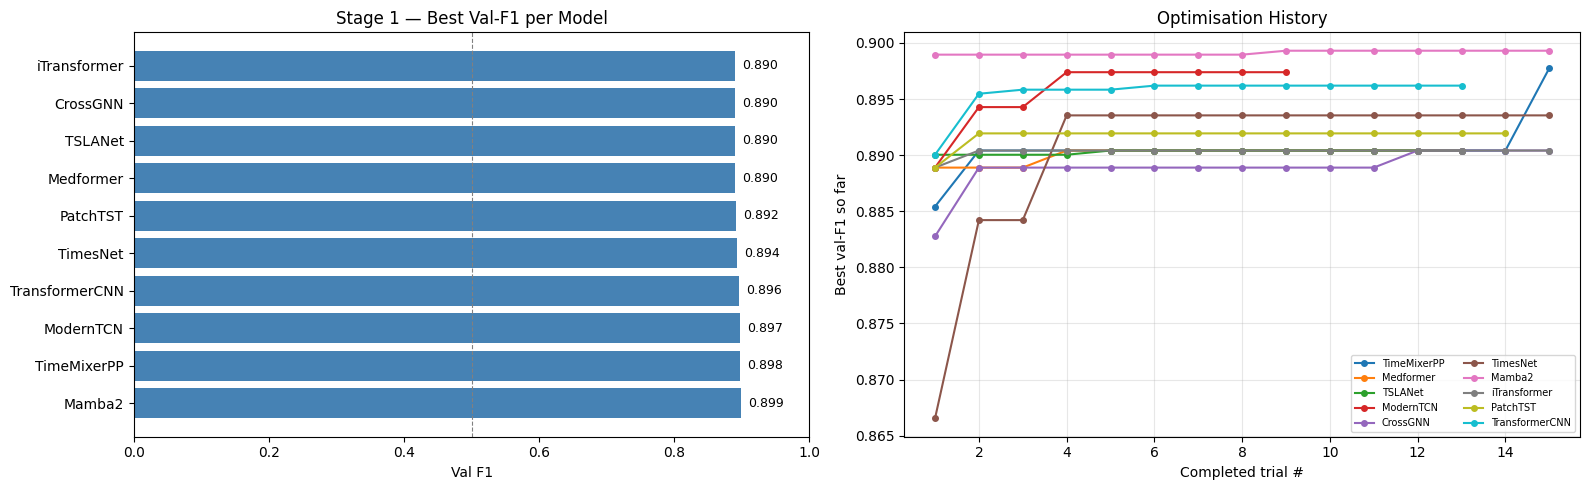

Figure saved → Save_model_HRV_OptunaStage1/optuna_stage1_results.png


In [22]:
# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar: val_f1 by model
ax = axes[0]
colors = ['steelblue' if v >= 0.5 else 'salmon'
          for v in df['val_f1'].fillna(0)]
ax.barh(df['model'], df['val_f1'].fillna(0), color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Val F1')
ax.set_title('Stage 1 — Best Val-F1 per Model')
ax.set_xlim(0, 1)
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row['val_f1'] + 0.01 if not pd.isna(row['val_f1']) else 0.01,
            i, f"{row['val_f1']:.3f}" if not pd.isna(row['val_f1']) else 'N/A',
            va='center', fontsize=9)

# Optimisation history per model
ax2 = axes[1]
for model_name in MODELS:
    study_name = f'stage1_{model_name}'
    try:
        study = optuna.load_study(study_name=study_name, storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if completed:
            vals = [t.value for t in completed]
            best_so_far = [max(vals[:i+1]) for i in range(len(vals))]
            ax2.plot(range(1, len(best_so_far) + 1), best_so_far,
                     marker='o', markersize=4, label=model_name)
    except Exception:
        pass
ax2.set_xlabel('Completed trial #')
ax2.set_ylabel('Best val-F1 so far')
ax2.set_title('Optimisation History')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = SAVE_DIR / 'optuna_stage1_results.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved → {fig_path}')

In [23]:
# ── Stage 1 Summary / Comparison Artifacts ───────────────────────────────────
import importlib
import HRV_optuna_utils as ou
ou = importlib.reload(ou)

summary_df = ou.generate_stage1_summary(study_results, e4_results_all, SAVE_DIR)
per_subject_df = ou.save_per_subject_results(e4_results_all, SAVE_DIR)

print('\n=== Stage 1 Summary (sorted by E4 F1) ===')
try:
    display(
        summary_df[['model', 'status', 'best_val_f1', 'e4_f1', 'e4_accuracy',
                    'e4_precision', 'e4_recall', 'e4_auroc',
                    'n_trials_completed', 'n_trials_pruned']]
        .style
        .format({c: '{:.4f}' for c in ['best_val_f1', 'e4_f1', 'e4_accuracy',
                                       'e4_precision', 'e4_recall', 'e4_auroc']},
                na_rep='N/A')
        .background_gradient(cmap='YlGn', subset=['best_val_f1', 'e4_f1'])
    )
except Exception:
    print(summary_df)

# Save a compact JSON snapshot of the summary for downstream use
summary_json_path = SAVE_DIR / 'stage1_summary.json'
summary_df.to_json(summary_json_path, orient='records', indent=2)
print(f'Saved: {summary_json_path}')

Saved: Save_model_HRV_OptunaStage1/stage1_summary.csv
Saved: Save_model_HRV_OptunaStage1/stage1_per_subject.csv

=== Stage 1 Summary (sorted by E4 F1) ===


,model,status,best_val_f1,e4_f1,e4_accuracy,e4_precision,e4_recall,e4_auroc,n_trials_completed,n_trials_pruned
0,TimeMixerPP,OK,0.8977,0.0667,0.1318,1.0000,0.0345,0.4684,15,0
1,Medformer,OK,0.8904,N/A,N/A,N/A,N/A,N/A,13,2
2,TSLANet,OK,0.8904,N/A,N/A,N/A,N/A,N/A,13,2
3,ModernTCN,OK,0.8974,N/A,N/A,N/A,N/A,N/A,9,6
4,CrossGNN,OK,0.8904,N/A,N/A,N/A,N/A,N/A,15,0
5,TimesNet,OK,0.8935,N/A,N/A,N/A,N/A,N/A,15,0
6,Mamba2,OK,0.8993,N/A,N/A,N/A,N/A,N/A,15,0
7,iTransformer,OK,0.8904,N/A,N/A,N/A,N/A,N/A,15,0
8,PatchTST,OK,0.8919,N/A,N/A,N/A,N/A,N/A,14,1
9,TransformerCNN,OK,0.8962,N/A,N/A,N/A,N/A,N/A,13,2


Saved: Save_model_HRV_OptunaStage1/stage1_summary.json


In [24]:
# ── E4 Missing-Value Diagnostics ─────────────────────────────────────────────
from pathlib import Path

print('\n=== E4 diagnostics ===')
missing_e4 = []
for model_name in MODELS:
    ckpt_path = SAVE_DIR / 'best_models' / f'{model_name}_best.pt'
    e4_result = e4_results_all.get(model_name)
    has_overall = bool(e4_result and e4_result.get('overall'))
    if not has_overall:
        missing_e4.append(model_name)

    try:
        study = optuna.load_study(study_name=f'stage1_{model_name}', storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        best_trial = max(completed, key=lambda t: t.value) if completed else None
        best_trial_num = best_trial.number if best_trial is not None else None
        best_trial_val = best_trial.value if best_trial is not None else None
    except Exception:
        best_trial_num = None
        best_trial_val = None

    n_e4_windows = int(sum(len(v[0]) for v in e4_data_per_subject.values()))
    print(
        f'{model_name:<16s} | ckpt={ckpt_path.exists()} | '
        f'e4_overall={has_overall} | total_e4_windows={n_e4_windows} | '
        f'best_trial={best_trial_num} | best_val={best_trial_val}'
    )

print('\nModels missing E4 overall metrics:', missing_e4 if missing_e4 else 'None')



=== E4 diagnostics ===
TimeMixerPP      | ckpt=True | e4_overall=True | total_e4_windows=774 | best_trial=15 | best_val=0.8977469620887335
Medformer        | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=3 | best_val=0.8904109539336649
TSLANet          | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=4 | best_val=0.8904109539336649
ModernTCN        | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=3 | best_val=0.8973912993623591
CrossGNN         | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=11 | best_val=0.8904109539336649
TimesNet         | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=3 | best_val=0.893542752428692
Mamba2           | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=8 | best_val=0.8993055505715905
iTransformer     | ckpt=True | e4_overall=False | total_e4_windows=774 | best_trial=1 | best_val=0.8904109539336649
PatchTST         | ckpt=True | e4_overall=False 

In [25]:
# ── Recompute E4 for all saved best checkpoints ──────────────────────────────
print('\n=== Recomputing E4 from saved checkpoints ===')
recomputed_e4_results = {}
recomputed_summary_rows = []
recompute_errors = {}

for model_name in MODELS:
    ckpt_path = SAVE_DIR / 'best_models' / f'{model_name}_best.pt'
    if not ckpt_path.exists():
        recompute_errors[model_name] = 'missing checkpoint'
        print(f'{model_name:<16s} | MISSING CHECKPOINT')
        continue

    try:
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        best_hp = {k: v for k, v in ckpt['hp'].items() if k not in {'bs', 'lr', 'wd'}}
        if model_name == 'Chronos2':
            best_hp['pipeline'] = chronos_pipeline
        best_model = build_model(model_name, W=W, n_channels=N_CHANNELS, **best_hp).to(DEVICE)
        best_model.load_state_dict(ckpt['model_state_dict'])

        e4_result = evaluate_on_e4(best_model, e4_data_per_subject, DEVICE, use_bf16=USE_BF16)
        recomputed_e4_results[model_name] = e4_result
        recomputed_summary_rows.append({
            'model': model_name,
            'e4_accuracy': e4_result['overall']['accuracy'] if e4_result['overall'] else float('nan'),
            'e4_f1': e4_result['overall']['f1'] if e4_result['overall'] else float('nan'),
            'e4_precision': e4_result['overall']['precision'] if e4_result['overall'] else float('nan'),
            'e4_recall': e4_result['overall']['recall'] if e4_result['overall'] else float('nan'),
            'e4_auroc': e4_result['overall'].get('auroc', float('nan')) if e4_result['overall'] else float('nan'),
            'n_windows': int(sum(len(v[0]) for v in e4_data_per_subject.values())),
        })
        print(f"{model_name:<16s} | OK | E4 F1={recomputed_summary_rows[-1]['e4_f1']:.4f}")
        del best_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception as e:
        recompute_errors[model_name] = repr(e)
        recomputed_e4_results[model_name] = None
        print(f'{model_name:<16s} | ERROR | {e}')

# Replace the in-memory results so downstream cells use the recomputed values.
e4_results_all = recomputed_e4_results

recomputed_summary_df = pd.DataFrame(recomputed_summary_rows)
if not recomputed_summary_df.empty:
    display(recomputed_summary_df.round(4))

with open(SAVE_DIR / 'e4_results_stage1.json', 'w') as f:
    json.dump(e4_results_all, f, indent=2)

summary_df = ou.generate_stage1_summary(study_results, e4_results_all, SAVE_DIR)
per_subject_df = ou.save_per_subject_results(e4_results_all, SAVE_DIR)
summary_json_path = SAVE_DIR / 'stage1_summary.json'
summary_df.to_json(summary_json_path, orient='records', indent=2)
print(f'Saved: {summary_json_path}')

print('\nRecompute errors:', recompute_errors if recompute_errors else 'None')



=== Recomputing E4 from saved checkpoints ===
TimeMixerPP      | OK | E4 F1=0.0667
Medformer        | OK | E4 F1=0.8747
TSLANet          | OK | E4 F1=0.3557
ModernTCN        | OK | E4 F1=0.1161
CrossGNN         | OK | E4 F1=0.6154
TimesNet         | OK | E4 F1=0.1137
Mamba2           | OK | E4 F1=0.0826
iTransformer     | OK | E4 F1=0.7763
PatchTST         | OK | E4 F1=0.2621
TransformerCNN   | OK | E4 F1=0.0000


,model,e4_accuracy,e4_f1,e4_precision,e4_recall,e4_auroc,n_windows
0,TimeMixerPP,0.1318,0.0667,1.0000,0.0345,0.4684,774
1,Medformer,0.7817,0.8747,0.9035,0.8477,0.5667,774
2,TSLANet,0.2791,0.3557,0.9059,0.2213,0.4549,774
3,ModernTCN,0.1537,0.1161,0.9556,0.0618,0.4470,774
4,CrossGNN,0.4767,0.6154,0.9076,0.4655,0.5330,774
5,TimesNet,0.1537,0.1137,0.9767,0.0603,0.4770,774
6,Mamba2,0.1395,0.0826,1.0000,0.0431,0.4500,774
7,iTransformer,0.6486,0.7763,0.9077,0.6782,0.5229,774
8,PatchTST,0.2287,0.2621,0.9381,0.1523,0.5338,774
9,TransformerCNN,0.1008,0.0000,0.0000,0.0000,0.3934,774


Saved: Save_model_HRV_OptunaStage1/stage1_summary.csv
Saved: Save_model_HRV_OptunaStage1/stage1_per_subject.csv
Saved: Save_model_HRV_OptunaStage1/stage1_summary.json

Recompute errors: None


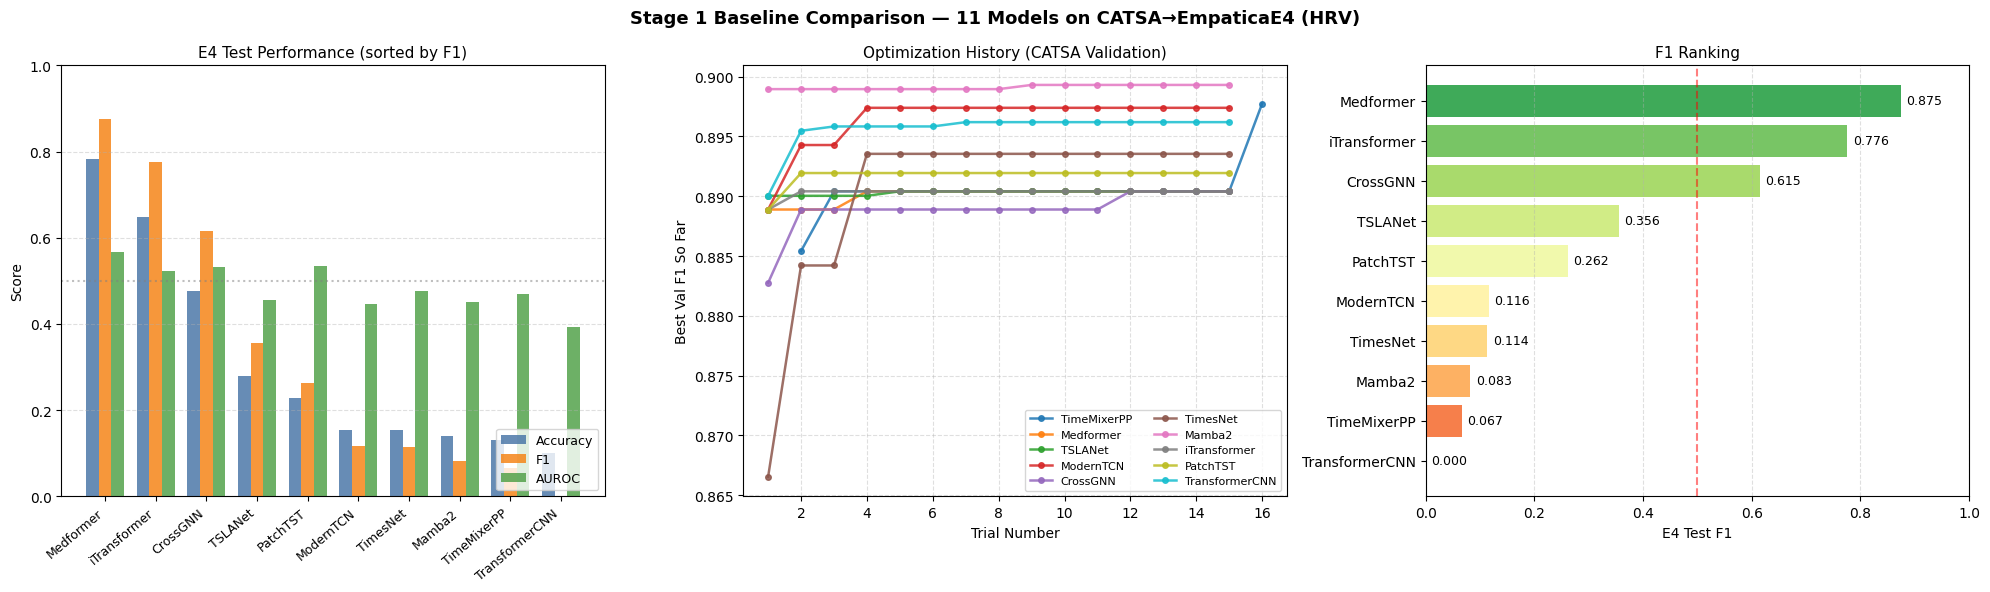

Saved: Save_model_HRV_OptunaStage1/stage1_comparison.png


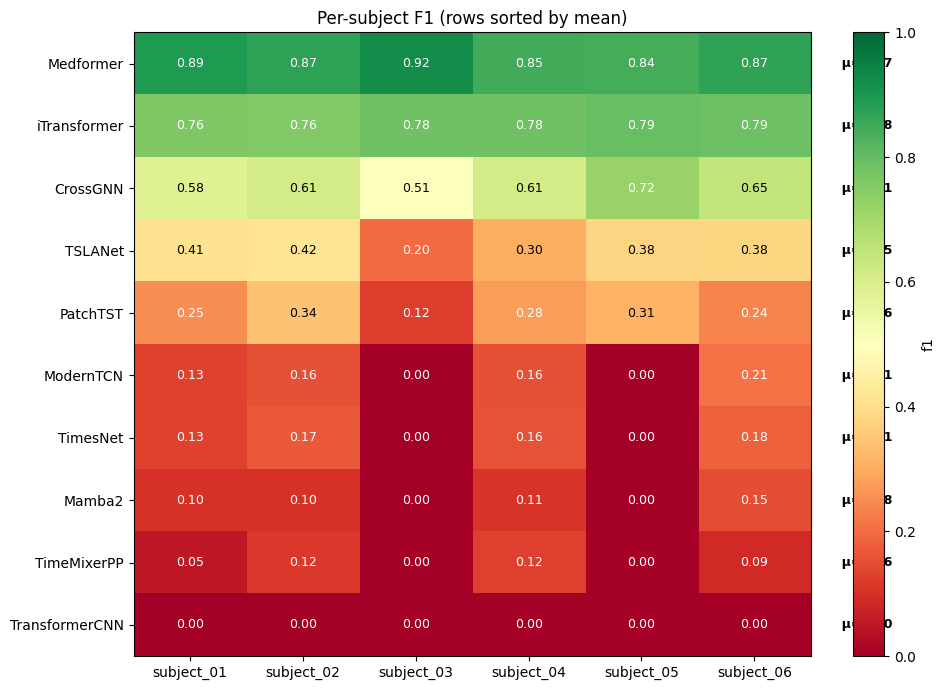

Saved: Save_model_HRV_OptunaStage1/stage1_per_subject_heatmap_f1.png
Plots saved to: Save_model_HRV_OptunaStage1/optuna_results

Comparison artifacts generated.


In [26]:
# ── Stage 1 Comparison Figures ────────────────────────────────────────────────
ou.plot_stage1_comparison(summary_df, study_results, SAVE_DIR, signal_name=SIGNAL)
ou.plot_per_subject_heatmap(per_subject_df, SAVE_DIR, metric='f1')
ou.save_hp_importance_plots(study_results, SAVE_DIR)

print('\nComparison artifacts generated.')

In [27]:
# ── Final Stage 1 Report ──────────────────────────────────────────────────────
print('\n' + '=' * 72)
print('STAGE 1 BASELINE RESULTS')
print('=' * 72)

valid = summary_df.dropna(subset=['e4_f1']).copy()
if len(valid) > 0:
    print('\nTop 3 models by E4 F1:')
    for rank, (_, row) in enumerate(valid.head(3).iterrows(), start=1):
        print(f"  {rank}. {row['model']:15s} | E4 F1: {row['e4_f1']:.4f} | Val F1: {row['best_val_f1']:.4f}")

    best_row = valid.iloc[0]
    print(f"\nBest model: {best_row['model']}")
    print(f"  Best HPs: lr={best_row['best_lr']:.2e}, bs={int(best_row['best_batch_size'])}, dropout={best_row['best_dropout']:.2f}")
    print(f"  Weight decay={best_row['best_weight_decay']:.2e}, focal_gamma={best_row['best_focal_gamma']}")
    print(f"  Model-specific: {best_row['best_model_specific']}")
    print(f"  E4 metrics: F1={best_row['e4_f1']:.4f}, Acc={best_row['e4_accuracy']:.4f}, AUROC={best_row['e4_auroc']:.4f}")

failed = summary_df[summary_df['status'] == 'FAILED']
if len(failed) > 0:
    print(f"\nFailed models: {failed['model'].tolist()}")

print('\nSaved outputs:')
print(f"  {SAVE_DIR / 'stage1_summary.csv'}")
print(f"  {SAVE_DIR / 'stage1_per_subject.csv'}")
print(f"  {SAVE_DIR / 'stage1_comparison.png'}")
print(f"  {SAVE_DIR / 'stage1_per_subject_heatmap_f1.png'}")
print(f"  {SAVE_DIR / 'optuna_results'}")
print('=' * 72)


STAGE 1 BASELINE RESULTS

Top 3 models by E4 F1:
  1. Medformer       | E4 F1: 0.8747 | Val F1: 0.8904
  2. iTransformer    | E4 F1: 0.7763 | Val F1: 0.8904
  3. CrossGNN        | E4 F1: 0.6154 | Val F1: 0.8904

Best model: Medformer
  Best HPs: lr=3.83e-04, bs=32, dropout=0.15
  Weight decay=6.73e-03, focal_gamma=2.0
  Model-specific: {"d_model": 128, "n_heads": 8, "n_layers": 4}
  E4 metrics: F1=0.8747, Acc=0.7817, AUROC=0.5667

Saved outputs:
  Save_model_HRV_OptunaStage1/stage1_summary.csv
  Save_model_HRV_OptunaStage1/stage1_per_subject.csv
  Save_model_HRV_OptunaStage1/stage1_comparison.png
  Save_model_HRV_OptunaStage1/stage1_per_subject_heatmap_f1.png
  Save_model_HRV_OptunaStage1/optuna_results


In [28]:
# ── Val-F1 vs E4-F1 Comparison & Top-3 Per-Subject Metrics
print('\n=== Val-F1 vs E4-F1 comparison & Top-3 per-subject metrics ===')
# Prepare comparison table
df_compare = summary_df[['model', 'best_val_f1', 'e4_f1', 'e4_accuracy', 'e4_auroc']].copy()
# Sort both ways
df_by_val = df_compare.sort_values('best_val_f1', ascending=False).reset_index(drop=True)
df_by_e4  = df_compare.sort_values('e4_f1', ascending=False).reset_index(drop=True)
print('\n-- Top by Val-F1 --')
display(df_by_val)
print('\n-- Top by E4-F1 --')
display(df_by_e4)
# Save ranking by E4
rank_csv = SAVE_DIR / 'stage1_val_vs_e4_rankings.csv'
df_by_e4.to_csv(rank_csv, index=False)
print(f'Saved: {rank_csv}')
# Top-3 by E4-F1 and per-subject metrics
top3 = df_by_e4.head(3)['model'].tolist()
print('\nTop-3 models by E4-F1:', top3)
per_subject_list = []
for m in top3:
    print(f"\nPer-subject metrics for {m}:")
    subdf = per_subject_df[per_subject_df['model'] == m].copy()
    if subdf.empty:
        print('  No per-subject data available.')
        continue
    # Ensure common columns exist before display
    cols = [c for c in ['subject', 'f1', 'accuracy', 'auroc', 'n_windows'] if c in subdf.columns]
    display(subdf[cols].round(4))
    per_subject_list.append(subdf)
# Save combined per-subject for top3
if per_subject_list:
    top3_per_subject_df = pd.concat(per_subject_list, ignore_index=True)
    per_csv = SAVE_DIR / 'stage1_top3_per_subject.csv'
    top3_per_subject_df.to_csv(per_csv, index=False)
    print(f'Saved: {per_csv}')



=== Val-F1 vs E4-F1 comparison & Top-3 per-subject metrics ===

-- Top by Val-F1 --


,model,best_val_f1,e4_f1,e4_accuracy,e4_auroc
0,Mamba2,0.899306,0.082645,0.139535,0.450026
1,TimeMixerPP,0.897747,0.066667,0.131783,0.468418
2,ModernTCN,0.897391,0.116059,0.153747,0.447014
3,TransformerCNN,0.896194,0.000000,0.100775,0.393429
4,TimesNet,0.893543,0.113667,0.153747,0.477002
5,PatchTST,0.891938,0.262052,0.228682,0.533829
6,iTransformer,0.890411,0.776316,0.648579,0.522942
7,Medformer,0.890411,0.874722,0.781654,0.566672
8,CrossGNN,0.890411,0.615385,0.476744,0.533046
9,TSLANet,0.890411,0.355658,0.279070,0.454926



-- Top by E4-F1 --


,model,best_val_f1,e4_f1,e4_accuracy,e4_auroc
0,Medformer,0.890411,0.874722,0.781654,0.566672
1,iTransformer,0.890411,0.776316,0.648579,0.522942
2,CrossGNN,0.890411,0.615385,0.476744,0.533046
3,TSLANet,0.890411,0.355658,0.279070,0.454926
4,PatchTST,0.891938,0.262052,0.228682,0.533829
5,ModernTCN,0.897391,0.116059,0.153747,0.447014
6,TimesNet,0.893543,0.113667,0.153747,0.477002
7,Mamba2,0.899306,0.082645,0.139535,0.450026
8,TimeMixerPP,0.897747,0.066667,0.131783,0.468418
9,TransformerCNN,0.896194,0.000000,0.100775,0.393429


Saved: Save_model_HRV_OptunaStage1/stage1_val_vs_e4_rankings.csv

Top-3 models by E4-F1: ['Medformer', 'iTransformer', 'CrossGNN']

Per-subject metrics for Medformer:


...


Per-subject metrics for iTransformer:


,subject,f1,accuracy,n_windows
42,subject_01,0.7603,0.6329,158
43,subject_02,0.7556,0.6154,143
44,subject_03,0.7849,0.6522,115
45,subject_04,0.7845,0.6695,118
46,subject_05,0.7937,0.6638,116
47,subject_06,0.7876,0.6694,124



Per-subject metrics for CrossGNN:


,subject,f1,accuracy,n_windows
24,subject_01,0.5837,0.4494,158
25,subject_02,0.6122,0.4685,143
26,subject_03,0.5067,0.3565,115
27,subject_04,0.6104,0.4915,118
28,subject_05,0.7222,0.5690,116
29,subject_06,0.6463,0.5323,124


Saved: Save_model_HRV_OptunaStage1/stage1_top3_per_subject.csv


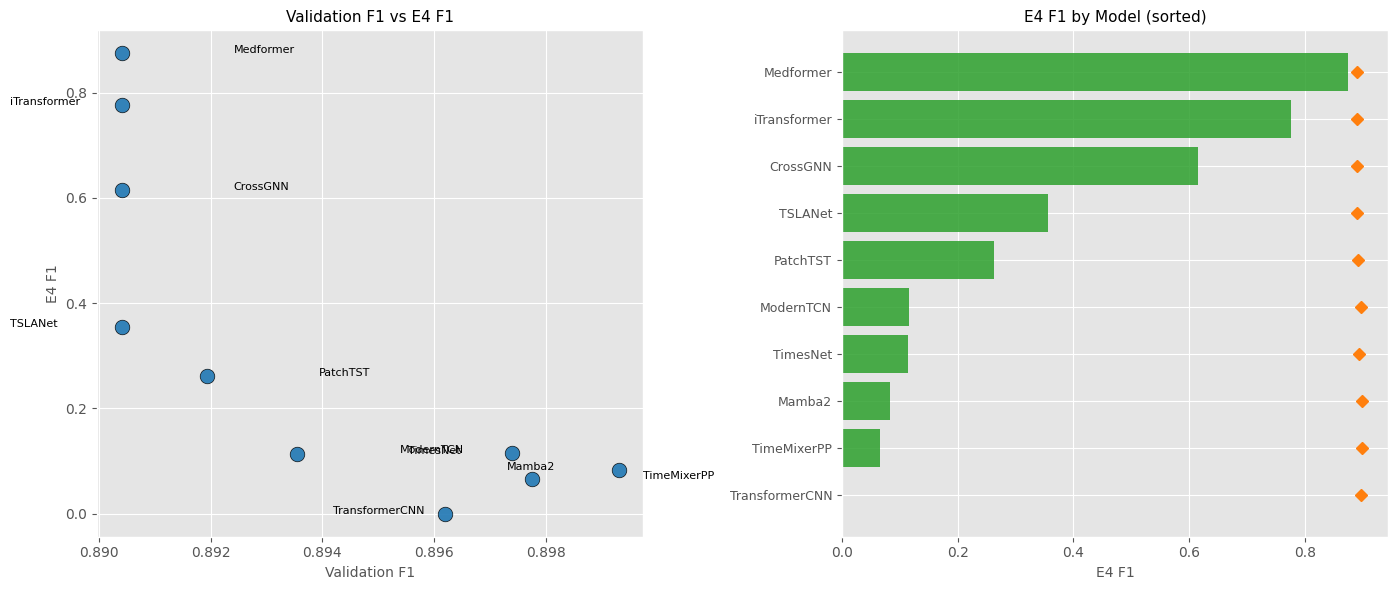

Saved plot → Save_model_HRV_OptunaStage1/stage1_val_vs_e4_plot.png


In [29]:
# ── Plot: Val-F1 vs E4-F1 (English labels, non-overlapping)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    from adjustText import adjust_text
    HAVE_ADJUST = True
except Exception:
    HAVE_ADJUST = False

plot_df = summary_df[['model', 'best_val_f1', 'e4_f1', 'e4_accuracy', 'e4_auroc']].dropna(subset=['best_val_f1','e4_f1']).copy()
plot_df = plot_df.reset_index(drop=True)

# Try a seaborn style, but fall back if it's not available in this env
try:
    plt.style.use('seaborn-whitegrid')
except Exception:
    try:
        plt.style.use('seaborn')
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Val-F1 vs E4-F1
ax0 = axes[0]
ax0.scatter(plot_df['best_val_f1'], plot_df['e4_f1'], s=110, color='tab:blue', edgecolor='k', alpha=0.9)
ax0.set_xlabel('Validation F1', fontsize=10)
ax0.set_ylabel('E4 F1', fontsize=10)
ax0.set_title('Validation F1 vs E4 F1', fontsize=11)
texts = []
for i, row in plot_df.iterrows():
    t = ax0.text(row['best_val_f1'], row['e4_f1'], row['model'], fontsize=8)
    texts.append(t)

if HAVE_ADJUST and texts:
    adjust_text(texts, ax=ax0, only_move={'points':'y','texts':'y'}, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))
else:
    # Minimal manual nudge to reduce overlap when adjustText is unavailable
    for i, t in enumerate(texts):
        x, y = t.get_position()
        shift = (0.002 if (i % 2 == 0) else -0.002)
        t.set_x(x + shift)

# Bar: E4-F1 by model (sorted) with Validation F1 overlay
ax1 = axes[1]
bar_df = plot_df.sort_values('e4_f1', ascending=True).reset_index(drop=True)
y_pos = list(range(len(bar_df)))
ax1.barh(y_pos, bar_df['e4_f1'], color='tab:green', alpha=0.85)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(bar_df['model'], fontsize=9)
ax1.set_xlabel('E4 F1', fontsize=10)
ax1.set_title('E4 F1 by Model (sorted)', fontsize=11)
# Overlay validation F1 as orange diamonds
for idx, row in bar_df.iterrows():
    ax1.plot(row['best_val_f1'], idx, 'D', color='tab:orange')

plt.tight_layout()
out_path = SAVE_DIR / 'stage1_val_vs_e4_plot.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved plot → {out_path}')


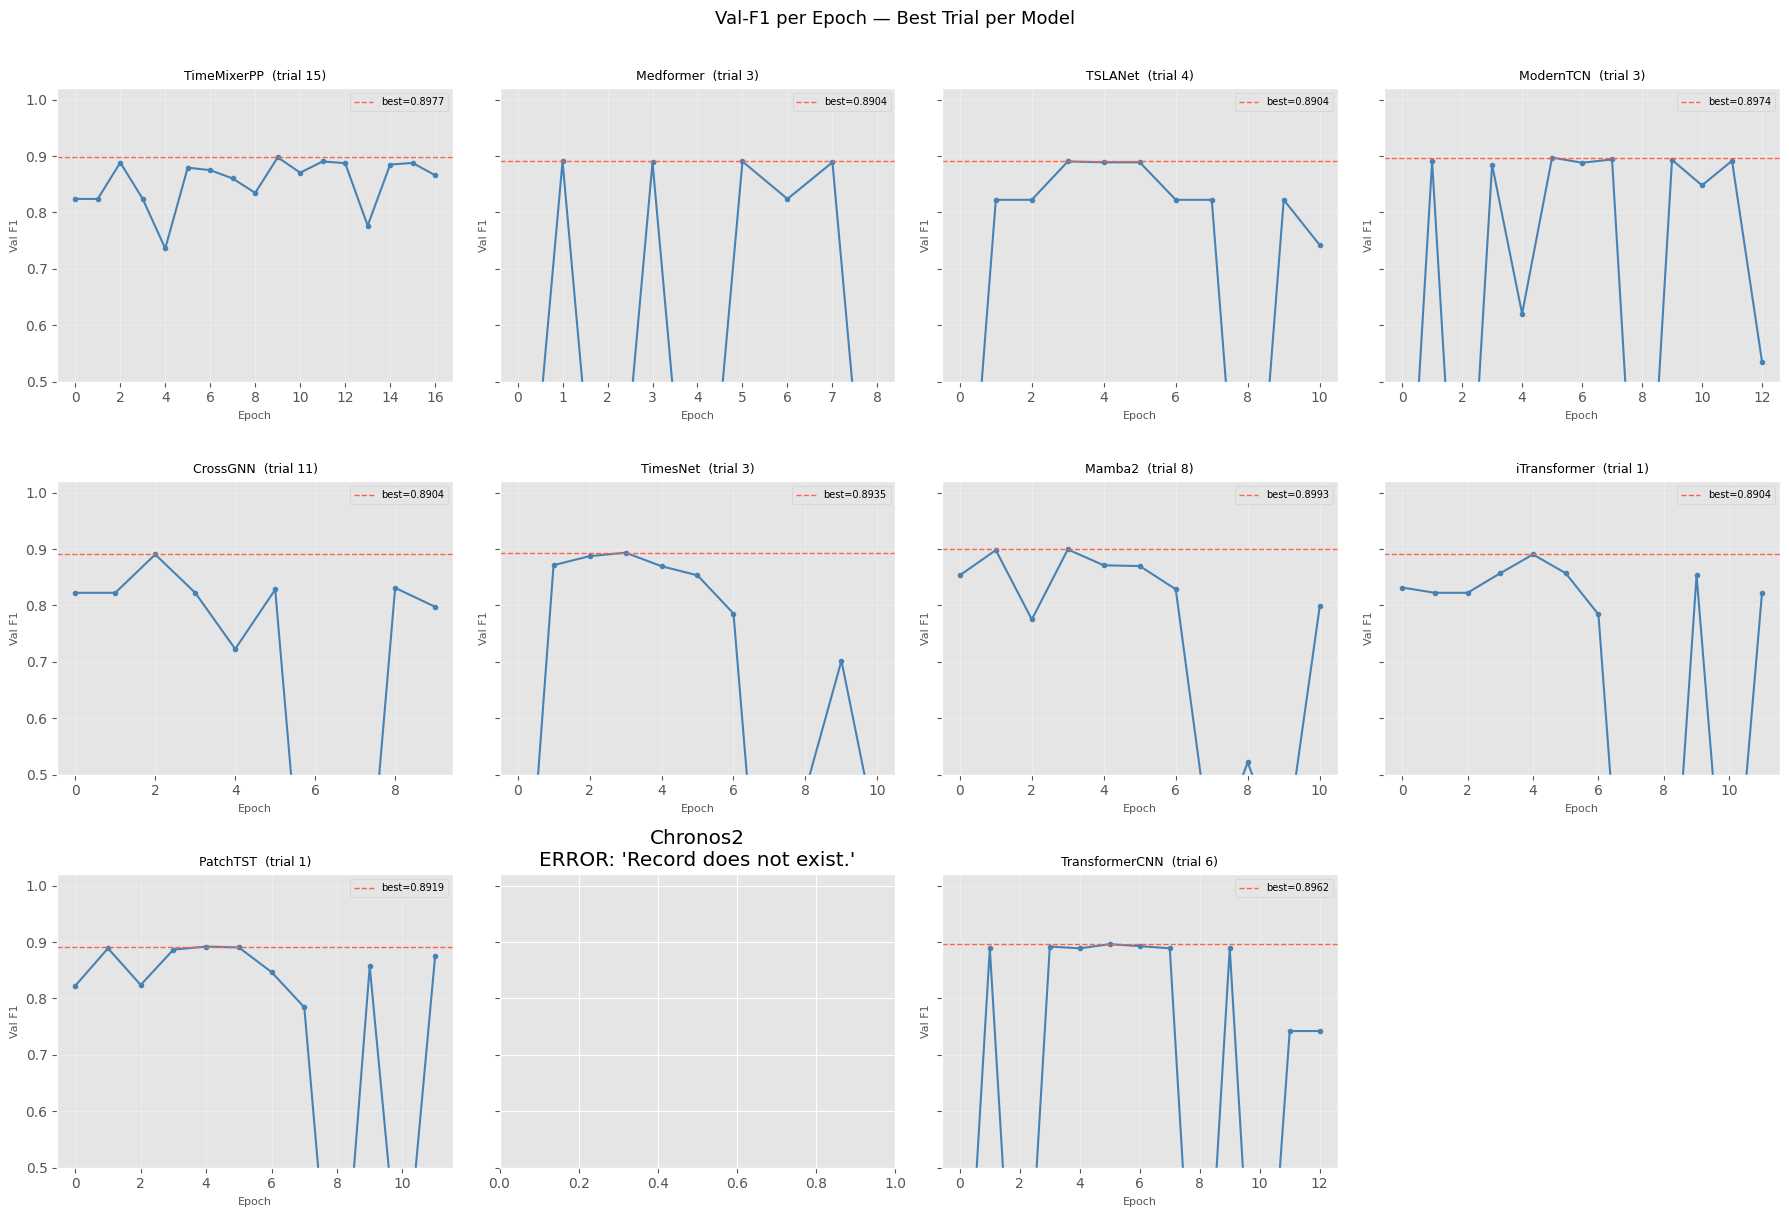

Saved → Save_model_HRV_OptunaStage1/stage1_val_f1_per_epoch.png


In [30]:
# ── Val-F1 per epoch (best trial per model) ───────────────────────────────────
import matplotlib.pyplot as plt
import optuna

ALL_MODELS = [
    'TimeMixerPP', 'Medformer', 'TSLANet', 'ModernTCN',
    'CrossGNN', 'TimesNet', 'Mamba2', 'iTransformer',
    'PatchTST', 'Chronos2', 'TransformerCNN',
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=False, sharey=True)
axes = axes.flatten()

for ax_idx, model_name in enumerate(ALL_MODELS):
    ax = axes[ax_idx]
    try:
        study = optuna.load_study(study_name=f'stage1_{model_name}', storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if not completed:
            ax.set_title(f'{model_name}\n(no completed trials)')
            continue

        best_trial = max(completed, key=lambda t: t.value)
        iv = best_trial.intermediate_values  # {epoch: val_f1}

        if not iv:
            ax.set_title(f'{model_name}\n(no epoch data)')
            continue

        epochs_sorted = sorted(iv.keys())
        vals = [iv[e] for e in epochs_sorted]

        ax.plot(epochs_sorted, vals, marker='o', markersize=3, linewidth=1.5, color='steelblue')
        ax.axhline(best_trial.value, color='tomato', linestyle='--', linewidth=1,
                   label=f'best={best_trial.value:.4f}')
        ax.set_title(f'{model_name}  (trial {best_trial.number})', fontsize=9)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel('Val F1', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.5, 1.02)

    except Exception as e:
        ax.set_title(f'{model_name}\nERROR: {e}')

# 빈 subplot 숨기기
for ax_idx in range(len(ALL_MODELS), len(axes)):
    axes[ax_idx].set_visible(False)

plt.suptitle('Val-F1 per Epoch — Best Trial per Model', fontsize=13, y=1.01)
plt.tight_layout()
out_path = SAVE_DIR / 'stage1_val_f1_per_epoch.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

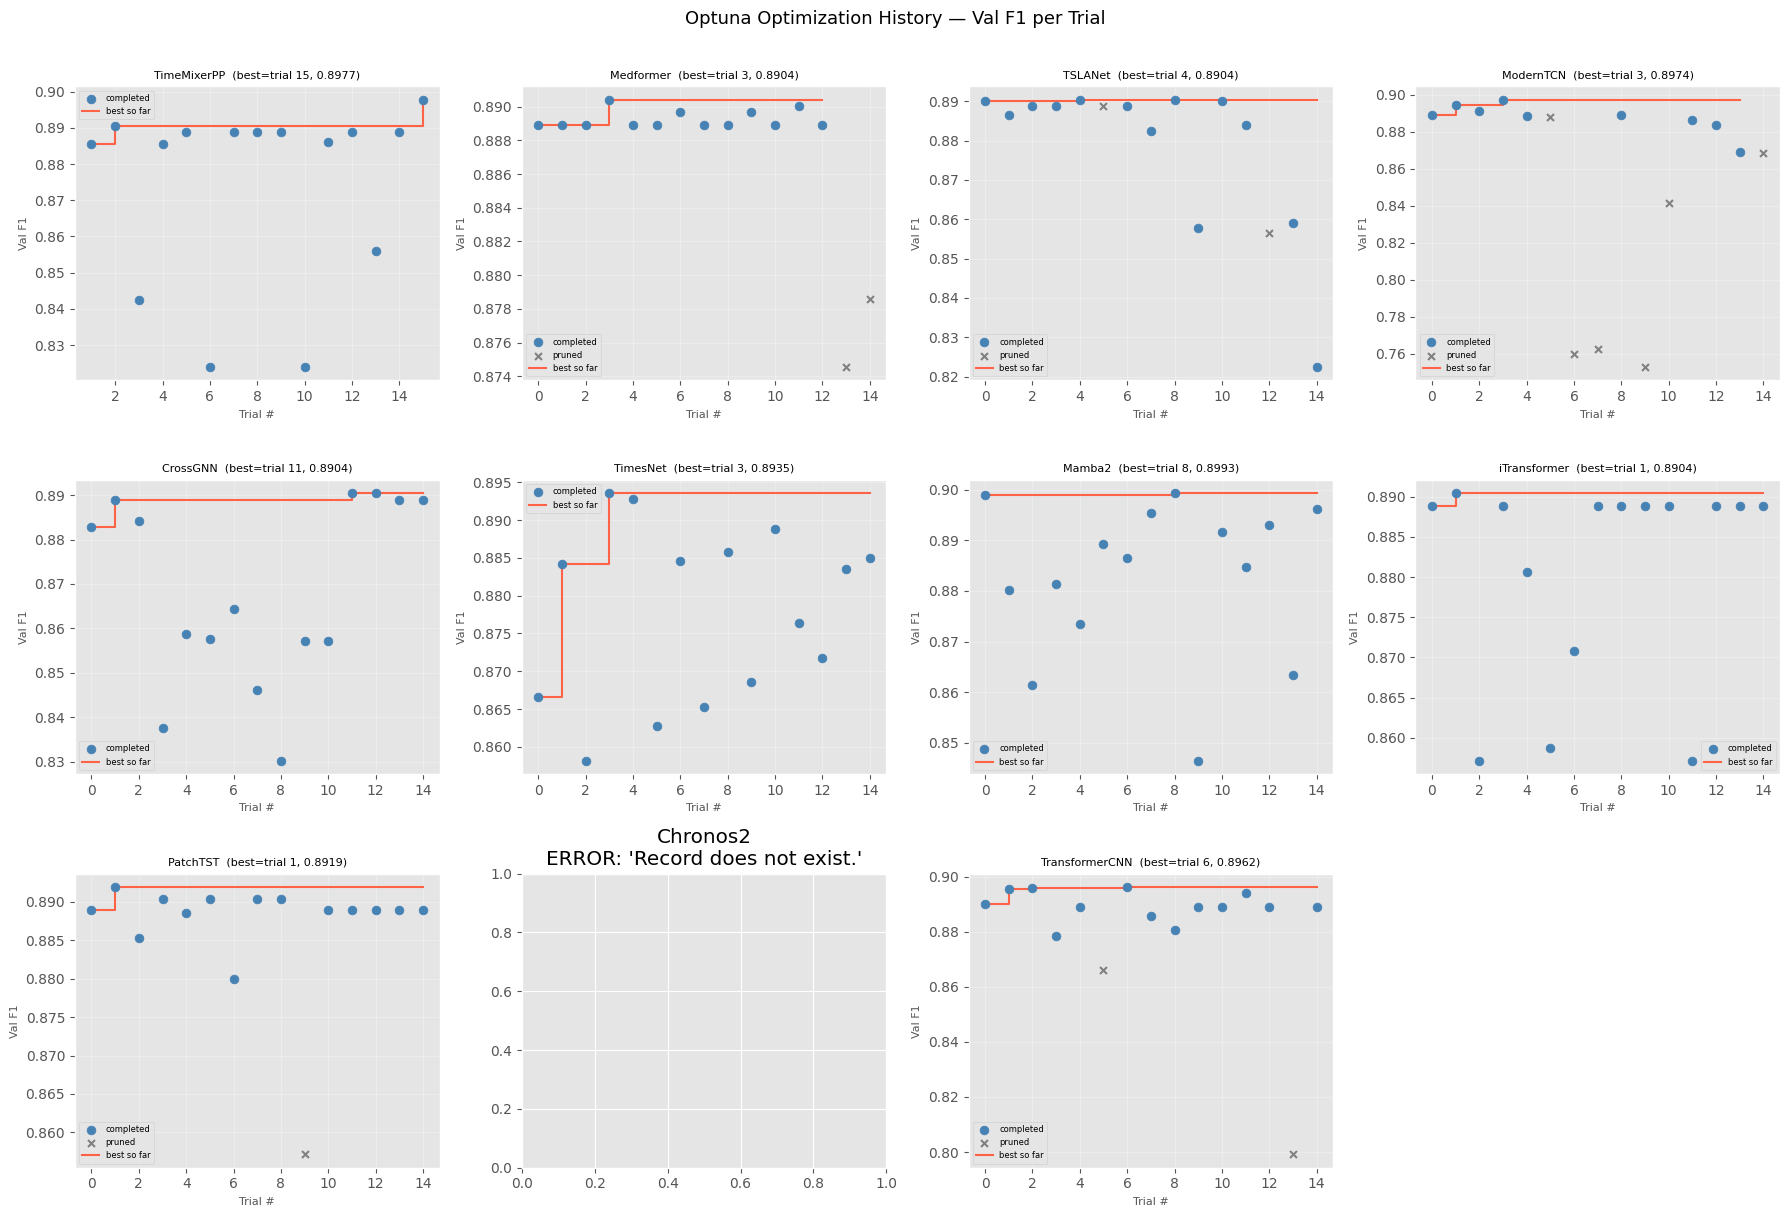

Saved → Save_model_HRV_OptunaStage1/stage1_optuna_history.png


In [31]:
# ── Optuna 최적화 히스토리: trial마다 val_f1 ─────────────────────────────────
import matplotlib.pyplot as plt
import optuna

ALL_MODELS = [
    'TimeMixerPP', 'Medformer', 'TSLANet', 'ModernTCN',
    'CrossGNN', 'TimesNet', 'Mamba2', 'iTransformer',
    'PatchTST', 'Chronos2', 'TransformerCNN',
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=False, sharey=False)
axes = axes.flatten()

for ax_idx, model_name in enumerate(ALL_MODELS):
    ax = axes[ax_idx]
    try:
        study = optuna.load_study(study_name=f'stage1_{model_name}', storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

        if not completed:
            ax.set_title(f'{model_name}\n(no completed trials)')
            continue

        # completed trials
        c_nums = [t.number for t in completed]
        c_vals = [t.value  for t in completed]
        ax.scatter(c_nums, c_vals, color='steelblue', s=40, zorder=3, label='completed')

        # pruned trials
        p_nums = [t.number for t in pruned if t.value is not None]
        p_vals = [t.value  for t in pruned if t.value is not None]
        if p_nums:
            ax.scatter(p_nums, p_vals, color='gray', s=25, marker='x', zorder=2, label='pruned')

        # best so far 선
        all_sorted = sorted(completed, key=lambda t: t.number)
        best, best_so_far = -1.0, []
        for t in all_sorted:
            best = max(best, t.value)
            best_so_far.append((t.number, best))
        xs, ys = zip(*best_so_far)
        ax.step(xs, ys, where='post', color='tomato', linewidth=1.5, label='best so far')

        best_trial = max(completed, key=lambda t: t.value)
        ax.set_title(f'{model_name}  (best=trial {best_trial.number}, {best_trial.value:.4f})', fontsize=8)
        ax.set_xlabel('Trial #', fontsize=8)
        ax.set_ylabel('Val F1', fontsize=8)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)

    except Exception as e:
        ax.set_title(f'{model_name}\nERROR: {e}')

for ax_idx in range(len(ALL_MODELS), len(axes)):
    axes[ax_idx].set_visible(False)

plt.suptitle('Optuna Optimization History — Val F1 per Trial', fontsize=13, y=1.01)
plt.tight_layout()
out_path = SAVE_DIR / 'stage1_optuna_history.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')